<a href="https://colab.research.google.com/github/dineshkarthikmcse2025-hue/DAA-EXPT/blob/main/DAA%20EXP%206.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Matrix Dimensions:
A1: 10 × 30
A2: 30 × 5
A3: 5 × 60
A4: 60 × 10

Minimum scalar multiplications: 5000
Optimal parenthesization: ((A1 × A2) × (A3 × A4))

DP Cost Table m[i][j]:

      A       1A       2A       3A       4
A1            0     1500     4500     5000
A2          ---        0     9000     4500
A3          ---      ---        0     3000
A4          ---      ---      ---        0


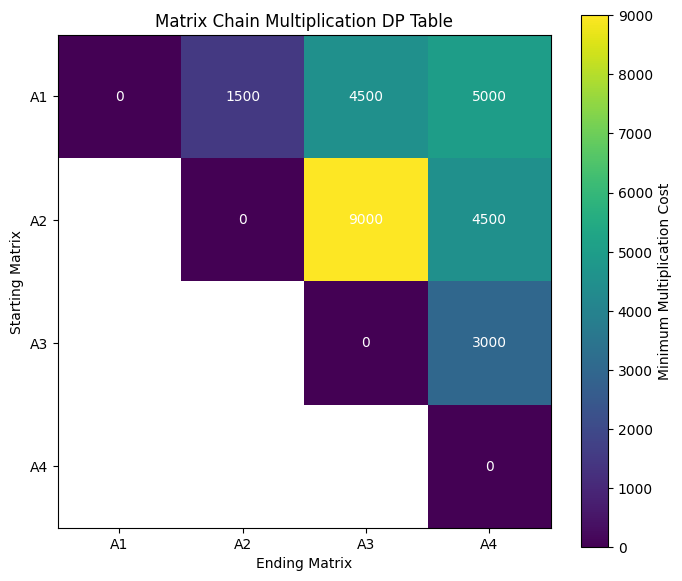

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def matrix_chain_order(dims):
    """
    Matrix Chain Multiplication using DP
    Time: O(n^3), Space: O(n^2)
    """
    n = len(dims) - 1

    # DP tables
    m = [[0] * (n + 1) for _ in range(n + 1)]
    s = [[0] * (n + 1) for _ in range(n + 1)]

    # l = chain length
    for l in range(2, n + 1):
        for i in range(1, n - l + 2):
            j = i + l - 1
            m[i][j] = float('inf')

            for k in range(i, j):
                cost = (
                    m[i][k]
                    + m[k + 1][j]
                    + dims[i - 1] * dims[k] * dims[j]
                )

                if cost < m[i][j]:
                    m[i][j] = cost
                    s[i][j] = k

    return m, s


def print_optimal_parens(s, i, j):
    if i == j:
        return f"A{i}"

    k = s[i][j]
    left = print_optimal_parens(s, i, k)
    right = print_optimal_parens(s, k + 1, j)

    return f"({left} × {right})"


def print_dp_table(m, n):
    print("\nDP Cost Table m[i][j]:\n")

    print(f'{"":>6}', end="")
    for j in range(1, n + 1):
        print(f'A{j:>8}', end="")
    print()

    for i in range(1, n + 1):
        print(f'A{i:<5}', end="")
        for j in range(1, n + 1):
            if j < i:
                print(f'{"---":>9}', end="")
            else:
                print(f'{m[i][j]:>9}', end="")
        print()


def plot_dp_table(m, n):
    """Display DP table as a heatmap."""

    data = np.full((n, n), np.nan)

    for i in range(1, n + 1):
        for j in range(i, n + 1):
            data[i - 1][j - 1] = m[i][j]

    plt.figure(figsize=(7, 6))

    plt.imshow(data, cmap="viridis")

    plt.colorbar(label="Minimum Multiplication Cost")

    plt.xticks(range(n), [f"A{i}" for i in range(1, n + 1)])
    plt.yticks(range(n), [f"A{i}" for i in range(1, n + 1)])

    plt.title("Matrix Chain Multiplication DP Table")
    plt.xlabel("Ending Matrix")
    plt.ylabel("Starting Matrix")

    # Show values inside cells
    for i in range(n):
        for j in range(n):
            if not np.isnan(data[i][j]):
                plt.text(
                    j,
                    i,
                    int(data[i][j]),
                    ha="center",
                    va="center",
                    color="white"
                )

    plt.tight_layout()
    plt.show()


# ---------------- MAIN ----------------

dims = [10, 30, 5, 60, 10]

n = len(dims) - 1

print("Matrix Dimensions:")
for i in range(n):
    print(f"A{i+1}: {dims[i]} × {dims[i+1]}")

m, s = matrix_chain_order(dims)

print("\nMinimum scalar multiplications:", m[1][n])
print("Optimal parenthesization:", print_optimal_parens(s, 1, n))

print_dp_table(m, n)

# Display graph
plot_dp_table(m, n)
